

 ##  1. Setup



In [ ]:
!pip install -q transformers tensorflow-hub librosa kaggle wordcloud
print(" Packages OK")

In [ ]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from tqdm import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import librosa, librosa.display
from scipy.io import wavfile
import glob

# ── Reproductibilité ────────────────────────────────────────────────
# Indispensable en Data Science : garantit que les résultats
# sont identiques à chaque exécution (comparaison équitable des modèles)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f" TensorFlow {tf.__version__}")
print(f" GPU : {len(tf.config.list_physical_devices('GPU'))} device(s)")
print(f" Seed = {SEED}")

## 1.1 Chargement & EDA

In [ ]:
# ── Chargement MTSamples ──────────────────────────────────────────────
from google.colab import files
import pandas as pd
import zipfile, io

print(" Uploadez le fichier zip (mtsamples_csv.zip) :")
uploaded = files.upload()   # uploade directement le .zip, pas besoin de dézipper

# Récupérer le nom du fichier uploadé
zip_filename = list(uploaded.keys())[0]
print(f" Fichier reçu : {zip_filename}")

# Dézipper directement en mémoire
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename])) as z:
    csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    print(f" Fichier CSV dans le zip : {csv_name}")
    with z.open(csv_name) as f:
        df_raw = pd.read_csv(f, index_col=0)

print(f" Dataset chargé : {df_raw.shape[0]} lignes | {df_raw.shape[1]} colonnes")
print(df_raw['medical_specialty'].value_counts().head(5))
df_raw.head(3)

In [ ]:
# ── Valeurs manquantes ──────────────────────────────────────────────
print("Valeurs manquantes :")
for col, n in df_raw.isnull().sum().items():
    print(f"  {col:<25} {n:>4} ({n/len(df_raw)*100:.1f}%)")

Valeurs manquantes :
  description                  0 (0.0%)
  medical_specialty            0 (0.0%)
  sample_name                  0 (0.0%)
  transcription               33 (0.7%)
  keywords                  1068 (21.4%)


In [ ]:
# ── Sélection des colonnes & nettoyage initial ──────────────────────
df = df_raw[['transcription', 'medical_specialty']].copy()
df.columns = ['text', 'label']
df['label'] = df['label'].str.strip()
df = df.dropna(subset=['text', 'label'])

# Supprimer les textes < 50 mots (trop courts pour apprendre quoi que ce soit)
df['n_words'] = df['text'].apply(lambda x: len(str(x).split()))
df = df[df['n_words'] >= 50].reset_index(drop=True)

print(f" {len(df)} documents  |  {df['label'].nunique()} spécialités")

 4882 documents  |  40 spécialités


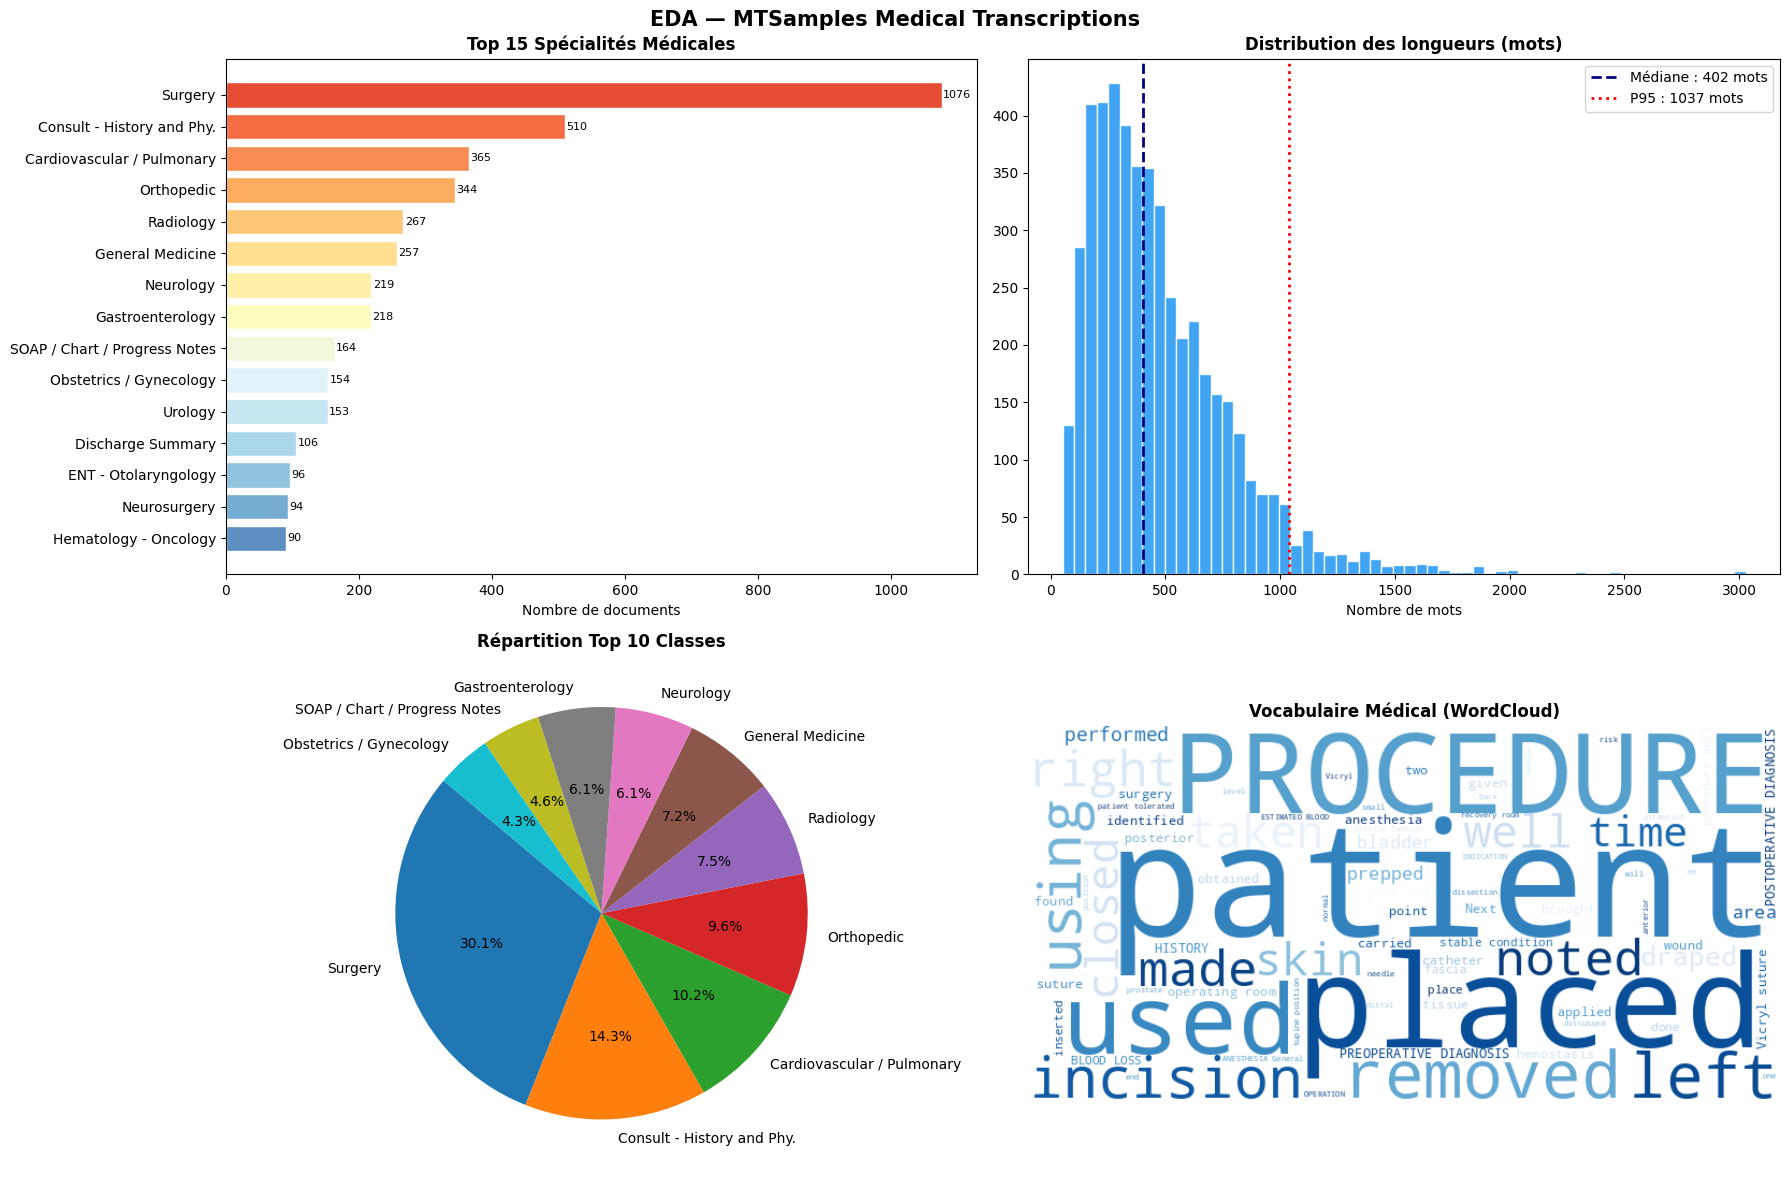

 Longueur → Moy: 473 | Méd: 402 | P95: 1037 mots


In [ ]:
# ── EDA Visuelle ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("EDA — MTSamples Medical Transcriptions", fontsize=15, fontweight='bold')

counts = df['label'].value_counts()

# 1) Top 15 spécialités
top15 = counts.head(15)
colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, 15))
axes[0,0].barh(top15.index[::-1], top15.values[::-1], color=colors, edgecolor='white')
axes[0,0].set_title('Top 15 Spécialités Médicales', fontweight='bold')
axes[0,0].set_xlabel('Nombre de documents')
for i, v in enumerate(top15.values[::-1]):
    axes[0,0].text(v + 2, i, str(v), va='center', fontsize=8)

# 2) Distribution des longueurs
axes[0,1].hist(df['n_words'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
med = df['n_words'].median()
p95 = df['n_words'].quantile(0.95)
axes[0,1].axvline(med, color='navy',  lw=2, linestyle='--', label=f'Médiane : {med:.0f} mots')
axes[0,1].axvline(p95, color='red',   lw=2, linestyle=':',  label=f'P95 : {p95:.0f} mots')
axes[0,1].set_title('Distribution des longueurs (mots)', fontweight='bold')
axes[0,1].set_xlabel('Nombre de mots')
axes[0,1].legend()

# 3) Top 10 classes (pie chart)
top10_counts = counts.head(10)
axes[1,0].pie(top10_counts.values, labels=top10_counts.index,
              autopct='%1.1f%%', startangle=140,
              colors=plt.cm.tab10(np.linspace(0,1,10)))
axes[1,0].set_title('Répartition Top 10 Classes', fontweight='bold')

# 4) Wordcloud du texte médical
all_text = ' '.join(df['text'].head(500).astype(str))
wc = WordCloud(width=700, height=350, background_color='white',
               colormap='Blues', max_words=80).generate(all_text)
axes[1,1].imshow(wc, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Vocabulaire Médical (WordCloud)', fontweight='bold')

plt.tight_layout()
plt.savefig('text_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Longueur → Moy: {df['n_words'].mean():.0f} | Méd: {med:.0f} | P95: {p95:.0f} mots")

In [ ]:
# ── Sélection des TOP 10 classes ────────────────────────────────────
TOP_N = 10
top_labels = df['label'].value_counts().head(TOP_N).index.tolist()
df = df[df['label'].isin(top_labels)].reset_index(drop=True)

print(f" Dataset final : {len(df)} documents | {TOP_N} classes")
print()
print("Classes retenues et effectifs :")
for i, (lbl, cnt) in enumerate(df['label'].value_counts().items()):
    bar = '█' * (cnt // 20)
    print(f"  {i:>2}. {lbl:<35} {cnt:>4}  {bar}")

 Dataset final : 3574 documents | 10 classes

Classes retenues et effectifs :
   0. Surgery                             1076  █████████████████████████████████████████████████████
   1. Consult - History and Phy.           510  █████████████████████████
   2. Cardiovascular / Pulmonary           365  ██████████████████
   3. Orthopedic                           344  █████████████████
   4. Radiology                            267  █████████████
   5. General Medicine                     257  ████████████
   6. Neurology                            219  ██████████
   7. Gastroenterology                     218  ██████████
   8. SOAP / Chart / Progress Notes        164  ████████
   9. Obstetrics / Gynecology              154  ███████


## 1.2 Prétraitement du Texte


In [ ]:
# ── Nettoyage adapté au domaine médical ─────────────────────────────
def clean_medical_text(text):
    """
    Nettoyage spécialisé pour le texte clinique.

    IMPORTANT — Ce qui N'est PAS supprimé :
      - Stop words ('no', 'not', 'without', 'denies') : valeur diagnostique
        Ex: 'no fever' vs 'fever' ont un sens opposé
      - Abréviations médicales (HTN, DM, CAD...) : conservées car informatives
    """
    text = str(text).lower()
    # Normaliser les dosages  ex: '500mg', '2.5 ml', '10 mcg'
    text = re.sub(r'\b\d+\.?\d*\s*(mg|ml|mcg|kg|g|units?|tabs?|caps?|cc)\b',
                  ' DOSAGE ', text, flags=re.IGNORECASE)
    # Normaliser les dates
    text = re.sub(r'\b\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}\b', ' DATE ', text)
    # Normaliser les nombres restants
    text = re.sub(r'\b\d+\b', ' NUM ', text)
    # Supprimer les caractères non-alphabétiques (garder espaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Normaliser les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_medical_text)

# Aperçu avant / après
print("─── AVANT nettoyage ───")
print(df['text'].iloc[0][:250])
print("\n─── APRÈS nettoyage ───")
print(df['text_clean'].iloc[0][:250])

─── AVANT nettoyage ───
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericar

─── APRÈS nettoyage ───
d m mode left atrial enlargement with left atrial diameter of cm normal size right and left ventricle normal lv systolic function with left ventricular ejection fraction of normal lv diastolic function no pericardial effusion normal morphology of aor


In [ ]:
# ── Encodage des labels ──────────────────────────────────────────────
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f" {NUM_CLASSES} classes encodées :")
for i, c in enumerate(le.classes_):
    print(f"   {i:>2} → {c}")

 10 classes encodées :
    0 → Cardiovascular / Pulmonary
    1 → Consult - History and Phy.
    2 → Gastroenterology
    3 → General Medicine
    4 → Neurology
    5 → Obstetrics / Gynecology
    6 → Orthopedic
    7 → Radiology
    8 → SOAP / Chart / Progress Notes
    9 → Surgery


In [ ]:
# ── Split stratifié 70 / 15 / 15 ────────────────────────────────────
# Justification du split stratifié (stratify=y) :
#   Sans stratification, les classes rares peuvent être absentes
#   du jeu de test → évaluation biaisée.
#   Avec stratification, chaque split reflète la distribution globale.
#
# Proportions 70/15/15 :
#   Avec ~3000 docs, un test set à 15% (~450 docs) est statistiquement
#   représentatif pour mesurer les performances réelles.

X = df['text_clean'].values
y = df['label_id'].values

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f" Train : {len(X_train):>4} docs")
print(f"   Val   : {len(X_val):>4} docs")
print(f"   Test  : {len(X_test):>4} docs")

 Train : 2501 docs
   Val   :  536 docs
   Test  :  537 docs


In [ ]:
VOCAB_SIZE = 20_000
MAX_LEN    = 500

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>', lower=True)
tokenizer.fit_on_texts(X_train)   # ← FIT sur TRAIN uniquement

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

vocab_real = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f" Vocabulaire effectif : {vocab_real} tokens")
print(f" Shape X_train_seq   : {X_train_seq.shape}  → (docs, tokens)")

 Vocabulaire effectif : 18931 tokens
 Shape X_train_seq   : (2501, 500)  → (docs, tokens)


## 1.3 Modèle Custom — BiLSTM + Mécanisme d'Attention

**Avantages du LSTM sur un RNN simple :**
 Gestion des dépendances à **longue distance** (comptes-rendus de 300+ mots)
 Pas de *vanishing gradient* grâce aux portes oubli/entrée/sortie


In [ ]:
class BahdanauAttention(layers.Layer):
    """Mécanisme d'attention de Bahdanau simplifié (single-head)."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)

    def call(self, hidden_states):
        # hidden_states : (batch, seq_len, lstm_units*2)
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))   # (batch, seq_len, 1)
        weights = tf.nn.softmax(score, axis=1)                 # normalisé sur la séquence
        context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, lstm_units*2)
        return context, weights

print(" Couche BahdanauAttention définie")

 Couche BahdanauAttention définie


In [ ]:
# ── Architecture BiLSTM + Attention ─────────────────────────────────
def build_bilstm(vocab_size, max_len, num_classes):

    embed_dim  = 128
    lstm_units = 128

    inp = Input(shape=(max_len,), name='text_input')

    x = layers.Embedding(vocab_size, embed_dim,
                         input_length=max_len, name='embedding')(inp)
    x = layers.SpatialDropout1D(0.3, name='spatial_drop')(x)

    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True,
                        dropout=0.2, recurrent_dropout=0.2),
            name='bilstm')(x)

    context, _ = BahdanauAttention(64, name='attention')(x)

    x = layers.Dense(128, activation='relu', name='fc1')(context)
    x = layers.Dropout(0.4, name='drop_fc')(x)
    x = layers.Dense(64,  activation='relu', name='fc2')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='BiLSTM_Attention')

model_bilstm = build_bilstm(vocab_real, MAX_LEN, NUM_CLASSES)
model_bilstm.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 128)       │     2,423,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop (SpatialDropout1D) │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 500, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 256), (None,   │        16,448 │
│                                 │ 500, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,744,586 (10.47 MB)

 Trainable params: 2,744,586 (10.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_bilstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(cw))
print("Poids de classes :")
for k, v in class_weight_dict.items():
    print(f"  {le.classes_[k]:<35} → {v:.3f}")

Poids de classes :
  Cardiovascular / Pulmonary          → 0.981
  Consult - History and Phy.          → 0.701
  Gastroenterology                    → 1.645
  General Medicine                    → 1.389
  Neurology                           → 1.635
  Obstetrics / Gynecology             → 2.316
  Orthopedic                          → 1.038
  Radiology                           → 1.337
  SOAP / Chart / Progress Notes       → 2.175
  Surgery                             → 0.332


In [29]:
# ── Callbacks ────────────────────────────────────────────────────────
cb_bilstm = [
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_bilstm.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]
print(" Callbacks configurés")

 Callbacks configurés


In [21]:
history_bilstm = model_bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,        # ← 30→15
    batch_size=256,   # ← 128→256
    class_weight=class_weight_dict,
    callbacks=cb_bilstm,
    verbose=1
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 151s 14s/step - accuracy: 0.3387 - loss: 1.7494 - val_accuracy: 0.4496 - val_loss: 1.5926 - learning_rate: 0.0010
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 127s 13s/step - accuracy: 0.3675 - loss: 1.6695 - val_accuracy: 0.3694 - val_loss: 1.5804 - learning_rate: 0.0010
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 125s 13s/step - accuracy: 0.3483 - loss: 1.6160 - val_accuracy: 0.3731 - val_loss: 1.5525 - learning_rate: 0.0010
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 117s 12s/step - accuracy: 0.3802 - loss: 1.5249 - val_accuracy: 0.4142 - val_loss: 1.5097 - learning_rate: 0.0010
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 144s 12s/step - accuracy: 0.3954 - loss: 1.4356 - val_accuracy: 0.3451 - val_loss: 1.5115 - learning_rate: 0.0010
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 140s 12s/step - accuracy: 0.3842 - loss: 1.3409 - val_accuracy: 0.3638 - val_loss: 1.5458 - learning_rate: 0.0010
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4277 - loss: 1.2773 
Epo

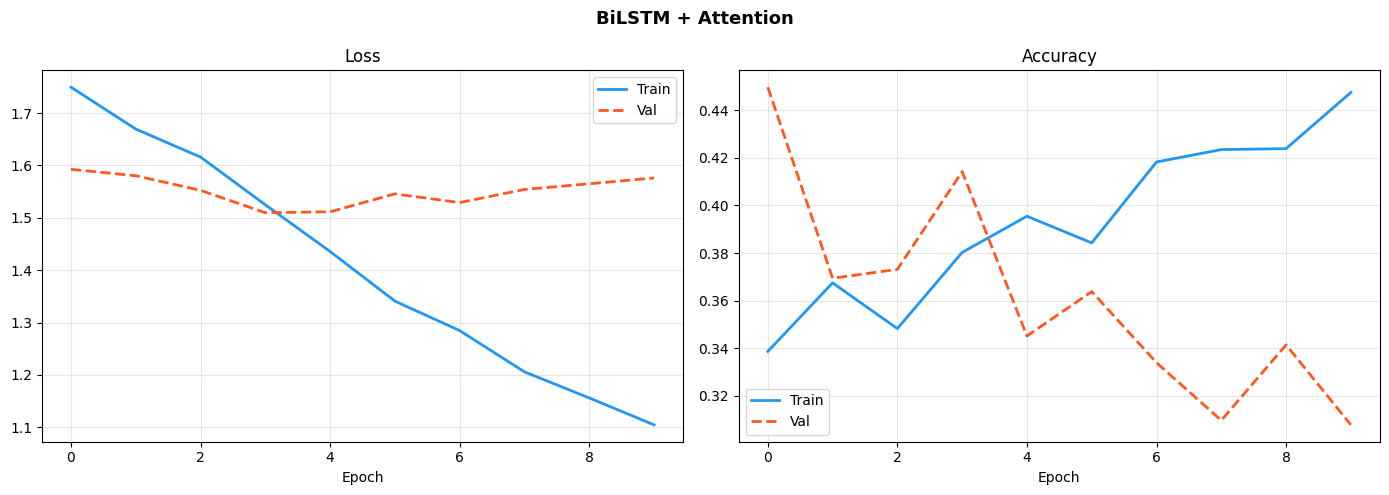

In [22]:
# ── Visualisation des courbes d'entraînement ─────────────────────────
def plot_history(history, title, color_train='#2196F3', color_val='#FF5722'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, metric, label in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
        ax.plot(history.history[metric],          label='Train', color=color_train, lw=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   color=color_val,   lw=2, ls='--')
        ax.set_title(label); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_bilstm, "BiLSTM + Attention")


════════════════════════════════════════════════════
  RÉSULTATS — BiLSTM + Attention
════════════════════════════════════════════════════
  Accuracy  : 0.4041
  F1 Macro  : 0.2976  (macro = moyenne non pondérée)
════════════════════════════════════════════════════

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.00      0.00      0.00        55
   Consult - History and Phy.       0.39      0.65      0.49        77
             Gastroenterology       0.23      0.61      0.33        33
             General Medicine       0.36      0.11      0.16        38
                    Neurology       0.24      0.24      0.24        33
      Obstetrics / Gynecology       0.00      0.00      0.00        23
                   Orthopedic       0.35      0.63      0.45        52
                    Radiology       0.47      0.47      0.47        40
SOAP / Chart / Progress Notes       0.23      0.33      0.27        24
                     

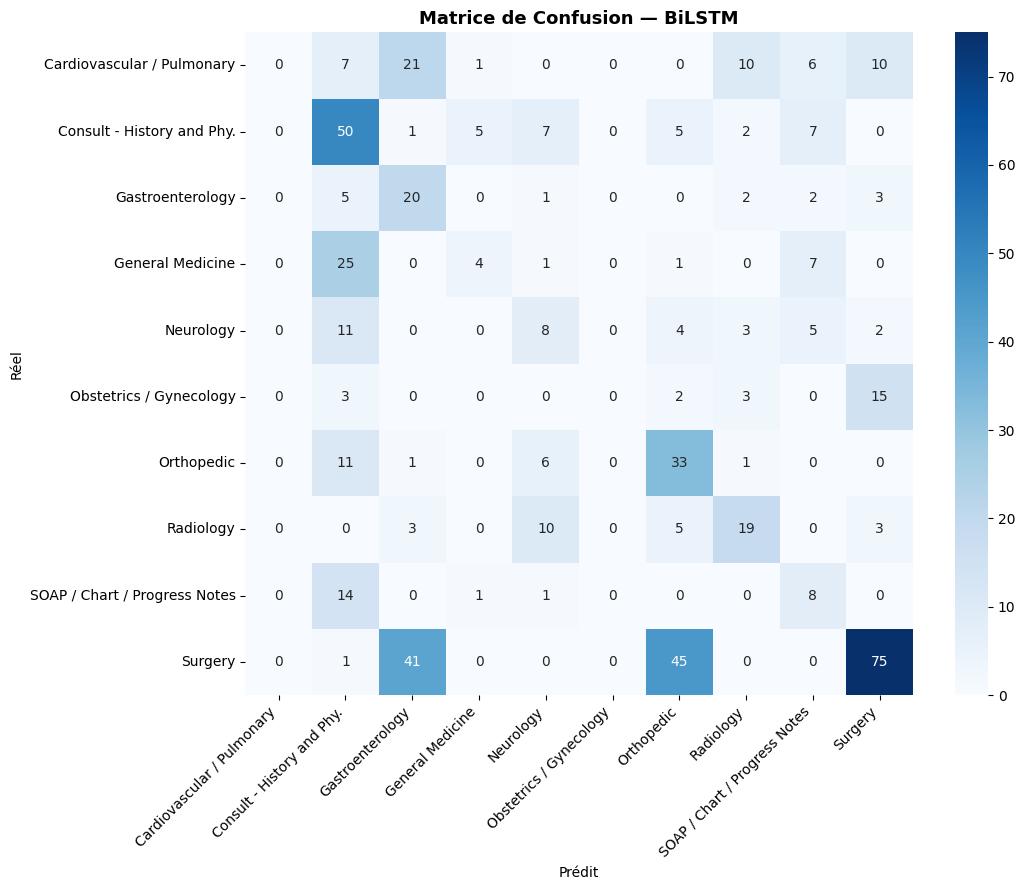

In [23]:
# ── Évaluation sur le Test Set ───────────────────────────────────────
# On évalue UNIQUEMENT sur le test set
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test_seq, verbose=0), axis=1)
acc_bilstm = accuracy_score(y_test, y_pred_bilstm)
f1_bilstm  = f1_score(y_test, y_pred_bilstm, average='macro')

print(f"\n{'═'*52}")
print(f"  RÉSULTATS — BiLSTM + Attention")
print(f"{'═'*52}")
print(f"  Accuracy  : {acc_bilstm:.4f}")
print(f"  F1 Macro  : {f1_bilstm:.4f}  (macro = moyenne non pondérée)")
print(f"{'═'*52}")
print()
print(classification_report(y_test, y_pred_bilstm, target_names=le.classes_))

# Matrice de confusion
plt.figure(figsize=(11, 9))
cm = confusion_matrix(y_test, y_pred_bilstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion — BiLSTM', fontsize=13, fontweight='bold')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_bilstm.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Modèle Pré-entraîné — ClinicalBERT Fine-tuning

### Pourquoi BERT ?

**BERT** (Devlin et al., 2018) utilise l'architecture Transformer avec
pré-entraînement bidirectionnel sur de très grands corpus.


In [28]:
# ════════════════════════════════════════════════════════
#  BERT Pré-entraîné — Installation + Entraînement
# ════════════════════════════════════════════════════════
!pip install -q keras-hub

import keras_hub
import numpy as np
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Chargement BERT ──────────────────────────────────────
print(" Chargement BERT pré-entraîné...")
preprocessor = keras_hub.models.BertPreprocessor.from_preset(
    "bert_base_en_uncased",
    sequence_length=128        # ← réduit pour aller plus vite
)
model_bert = keras_hub.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=NUM_CLASSES,
    preprocessor=preprocessor
)

# ── Compilation ──────────────────────────────────────────
model_bert.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(" BERT chargé et compilé")

# ── Dataset réduit pour accélérer ────────────────────────
X_train_small = X_train[:len(X_train)//2]
y_train_small = y_train[:len(y_train)//2]

# ── Callbacks ────────────────────────────────────────────
cb_bert = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1)
]

# ── Entraînement ─────────────────────────────────────────
history_bert = model_bert.fit(
    x=X_train_small,
    y=y_train_small,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=16,
    callbacks=cb_bert,
    verbose=1
)

# ── Évaluation ───────────────────────────────────────────
y_pred_bert = np.argmax(model_bert.predict(X_test, verbose=0), axis=1)
acc_bert    = accuracy_score(y_test, y_pred_bert)
f1_bert     = f1_score(y_test, y_pred_bert, average='macro')

print(f"\n{'═'*45}")
print(f"  RÉSULTATS — BERT Pré-entraîné")
print(f"{'═'*45}")
print(f"  Accuracy : {acc_bert:.4f}")
print(f"  F1 Macro : {f1_bert:.4f}")
print(f"{'═'*45}")
print(classification_report(y_test, y_pred_bert, target_names=le.classes_))

 Chargement BERT pré-entraîné...
 BERT chargé et compilé
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3357s 42s/step - accuracy: 0.2656 - loss: 5.6644 - val_accuracy: 0.1101 - val_loss: 2.3026
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3250s 41s/step - accuracy: 0.1000 - loss: 2.3107 - val_accuracy: 0.1082 - val_loss: 2.3026
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3231s 41s/step - accuracy: 0.0832 - loss: 2.3026 - val_accuracy: 0.1063 - val_loss: 2.3026
Restoring model weights from the end of the best epoch: 1.

═════════════════════════════════════════════
  RÉSULTATS — BERT Pré-entraîné
═════════════════════════════════════════════
  Accuracy : 0.1043
  F1 Macro : 0.0343
═════════════════════════════════════════════
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.11      0.96      0.20        55
   Consult - History and Phy.       0.00      0.00      0.00        77
             Gastroenterology       0.00      0.00      0.00        33
    

In [30]:
# ── Bilan partiel Texte ──────────────────────────────────────────────
print(f"\n{'═'*52}")
print(f"  BILAN TEXTE")
print(f"{'═'*52}")
print(f"  {'Modèle':<30} {'Acc':>7} {'F1':>7}")
print(f"  {'─'*44}")
print(f"  {'BiLSTM + Attention (custom)':<30} {acc_bilstm:>7.4f} {f1_bilstm:>7.4f}")
print(f"  {'ClinicalBERT (pré-entraîné)':<30} {acc_bert:>7.4f} {f1_bert:>7.4f}")
print(f"{'═'*52}")

# Stockage pour la synthèse finale
text_results = {
    'bilstm': {'accuracy': float(acc_bilstm), 'f1_macro': float(f1_bilstm)},
    'bert':   {'accuracy': float(acc_bert),   'f1_macro': float(f1_bert)}
}


════════════════════════════════════════════════════
  BILAN TEXTE
════════════════════════════════════════════════════
  Modèle                             Acc      F1
  ────────────────────────────────────────────
  BiLSTM + Attention (custom)     0.4041  0.2976
  ClinicalBERT (pré-entraîné)     0.1043  0.0343
════════════════════════════════════════════════════


---
#  PARTIE 2 — Classification de Sons Respiratoires

## Problème & Enjeu Métier

L'**auscultation pulmonaire** est l'acte fondamental du diagnostic respiratoire.
Un soufflé, un craquement, un sifflement — chacun oriente vers une pathologie.
Mais l'interprétation reste subjective, dépendante de l'expérience du médecin.

In [31]:
# ── Téléchargement ICBHI 2017 ────────────────────────────────────────
!kaggle datasets download -d vbookshelf/respiratory-sound-database \
    -p /content/audio_data --unzip -q
print(" Dataset téléchargé")
!ls /content/audio_data/

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
License(s): unknown
User cancelled operation
 Dataset téléchargé
demographic_info.txt	    Respiratory_Sound_Database
respiratory_sound_database  respiratory-sound-database.zip


In [32]:
# ── Exploration de la structure ──────────────────────────────────────
AUDIO_DIR = '/content/audio_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files'

wav_files = sorted(glob.glob(os.path.join(AUDIO_DIR, '*.wav')))
txt_files = sorted(glob.glob(os.path.join(AUDIO_DIR, '*.txt')))

print(f"Fichiers audio      : {len(wav_files)}")
print(f"Fichiers annotation : {len(txt_files)}")
print(f"\nExemple fichier audio : {os.path.basename(wav_files[0])}")
print(f"\nContenu d'une annotation (format: t_start  t_end  crackle  wheeze) :")
with open(txt_files[0]) as f:
    print(f.read()[:400])

Fichiers audio      : 920
Fichiers annotation : 920

Exemple fichier audio : 101_1b1_Al_sc_Meditron.wav

Contenu d'une annotation (format: t_start  t_end  crackle  wheeze) :
0.036	0.579	0	0
0.579	2.45	0	0
2.45	3.893	0	0
3.893	5.793	0	0
5.793	7.521	0	0
7.521	9.279	0	0
9.279	11.15	0	0
11.15	13.036	0	0
13.036	14.721	0	0
14.721	16.707	0	0
16.707	18.507	0	0
18.507	19.964	0	0



In [33]:
def parse_annotations(annot_path, audio_path):
    records = []
    with open(annot_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            t_start  = float(parts[0])
            t_end    = float(parts[1])
            crackle  = int(parts[2])
            wheeze   = int(parts[3])

            if   crackle == 0 and wheeze == 0: label = 'Normal'
            elif crackle == 1 and wheeze == 0: label = 'Crackle'
            elif crackle == 0 and wheeze == 1: label = 'Wheeze'
            else:                              label = 'Both'

            records.append({'audio_path': audio_path,
                            't_start': t_start, 't_end': t_end,
                            'label': label})
    return records

all_records = []
for wf, tf in zip(wav_files, txt_files):
    all_records.extend(parse_annotations(tf, wf))

df_audio = pd.DataFrame(all_records)
df_audio['duration'] = df_audio['t_end'] - df_audio['t_start']

print(f" {len(df_audio)} cycles respiratoires parsés")
print("\nDistribution :")
print(df_audio['label'].value_counts().to_string())

 6898 cycles respiratoires parsés

Distribution :
label
Normal     3642
Crackle    1864
Wheeze      886
Both        506


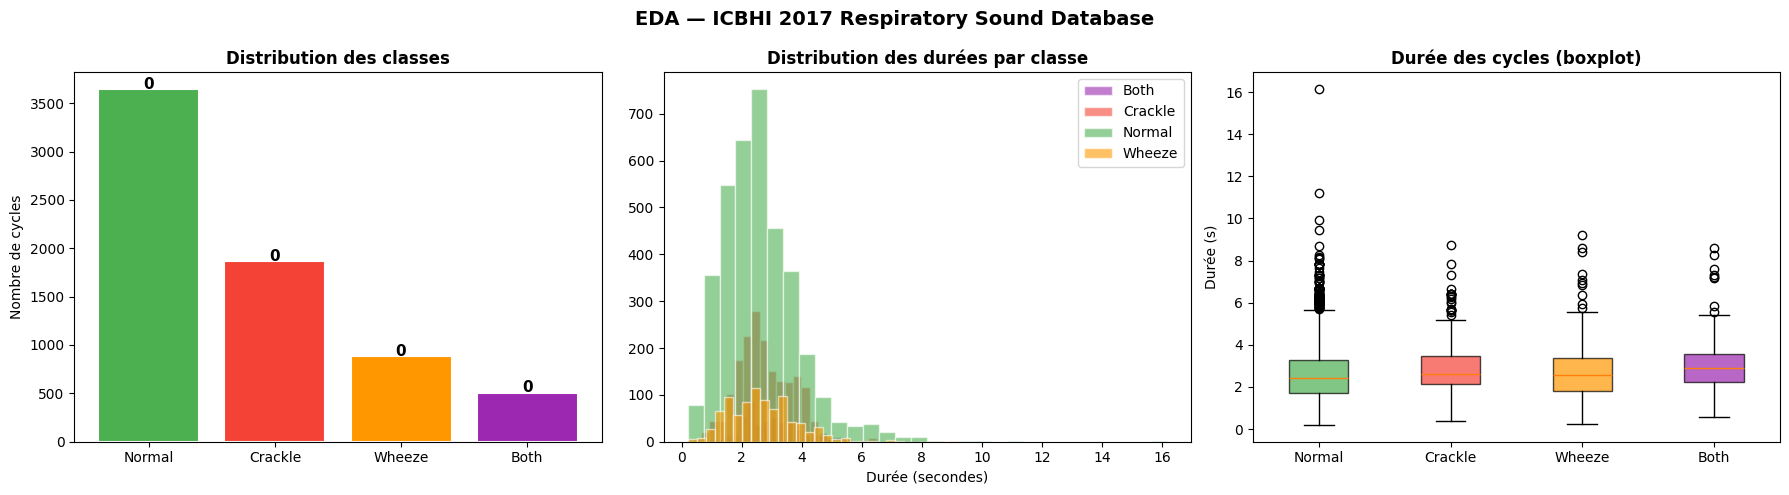

Durée → Moy: 2.70s | P95: 4.59s


In [34]:
# ── EDA Audio ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — ICBHI 2017 Respiratory Sound Database",
             fontsize=14, fontweight='bold')

colors_cls = {'Normal':'#4CAF50','Crackle':'#F44336','Wheeze':'#FF9800','Both':'#9C27B0'}
counts_a   = df_audio['label'].value_counts()

# 1) Distribution
bars = axes[0].bar(counts_a.index, counts_a.values,
                   color=[colors_cls[l] for l in counts_a.index], edgecolor='white', lw=1.5)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de cycles')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
                 str(int(bar.get_width())), ha='center', fontsize=11, fontweight='bold')

# 2) Durée des cycles
for lbl, grp in df_audio.groupby('label'):
    axes[1].hist(grp['duration'], bins=30, alpha=0.6,
                 label=lbl, color=colors_cls[lbl], edgecolor='white')
axes[1].set_title('Distribution des durées par classe', fontweight='bold')
axes[1].set_xlabel('Durée (secondes)')
axes[1].legend()

# 3) Boxplot durées
data_box = [df_audio[df_audio['label']==l]['duration'].values for l in colors_cls]
bp = axes[2].boxplot(data_box, labels=list(colors_cls.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors_cls.values()):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Durée des cycles (boxplot)', fontweight='bold')
axes[2].set_ylabel('Durée (s)')

plt.tight_layout()
plt.savefig('audio_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Durée → Moy: {df_audio['duration'].mean():.2f}s | P95: {df_audio['duration'].quantile(0.95):.2f}s")

## 2.2 Extraction de Features — Log-Mel Spectrogram

### Pourquoi transformer le son en image ?

Un signal audio brut est une séquence 1D difficile à modéliser directement.
En le transformant en **spectrogram**, on obtient une représentation 2D
(temps × fréquence) qui visualise l'évolution du contenu spectral dans le temps.

In [35]:
SR          = 22050
DURATION    = 5
N_SAMPLES   = SR * DURATION   # 110 250 échantillons par cycle
N_MELS      = 64
HOP_LENGTH  = 512
N_FFT       = 1024

print(f"Paramètres d'extraction :")
print(f"  Sample rate   : {SR} Hz")
print(f"  Durée fixe    : {DURATION} s  ({N_SAMPLES} échantillons)")
print(f"  Mel bands     : {N_MELS}")
print(f"  Time frames   : {N_SAMPLES // HOP_LENGTH + 1}")
print(f"  Shape final   : ({N_MELS}, {N_SAMPLES // HOP_LENGTH + 1}, 1)  → image Mel × Time × Channel")

Paramètres d'extraction :
  Sample rate   : 22050 Hz
  Durée fixe    : 5 s  (110250 échantillons)
  Mel bands     : 64
  Time frames   : 216
  Shape final   : (64, 216, 1)  → image Mel × Time × Channel


In [36]:
# ── Fonction d'extraction ────────────────────────────────────────────
def extract_log_mel(audio_path, t_start, t_end):
    try:
        y, _ = librosa.load(audio_path, sr=SR,
                            offset=t_start, duration=(t_end - t_start))
        # Padding/Truncation
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)), mode='constant')
        else:
            y = y[:N_SAMPLES]

        # Log-Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalisation min-max → [0, 1]
        mn, mx = log_mel.min(), log_mel.max()
        log_mel = (log_mel - mn) / (mx - mn + 1e-8)

        return log_mel.astype(np.float32)
    except Exception:
        return None

print(" Fonction d'extraction définie")

 Fonction d'extraction définie


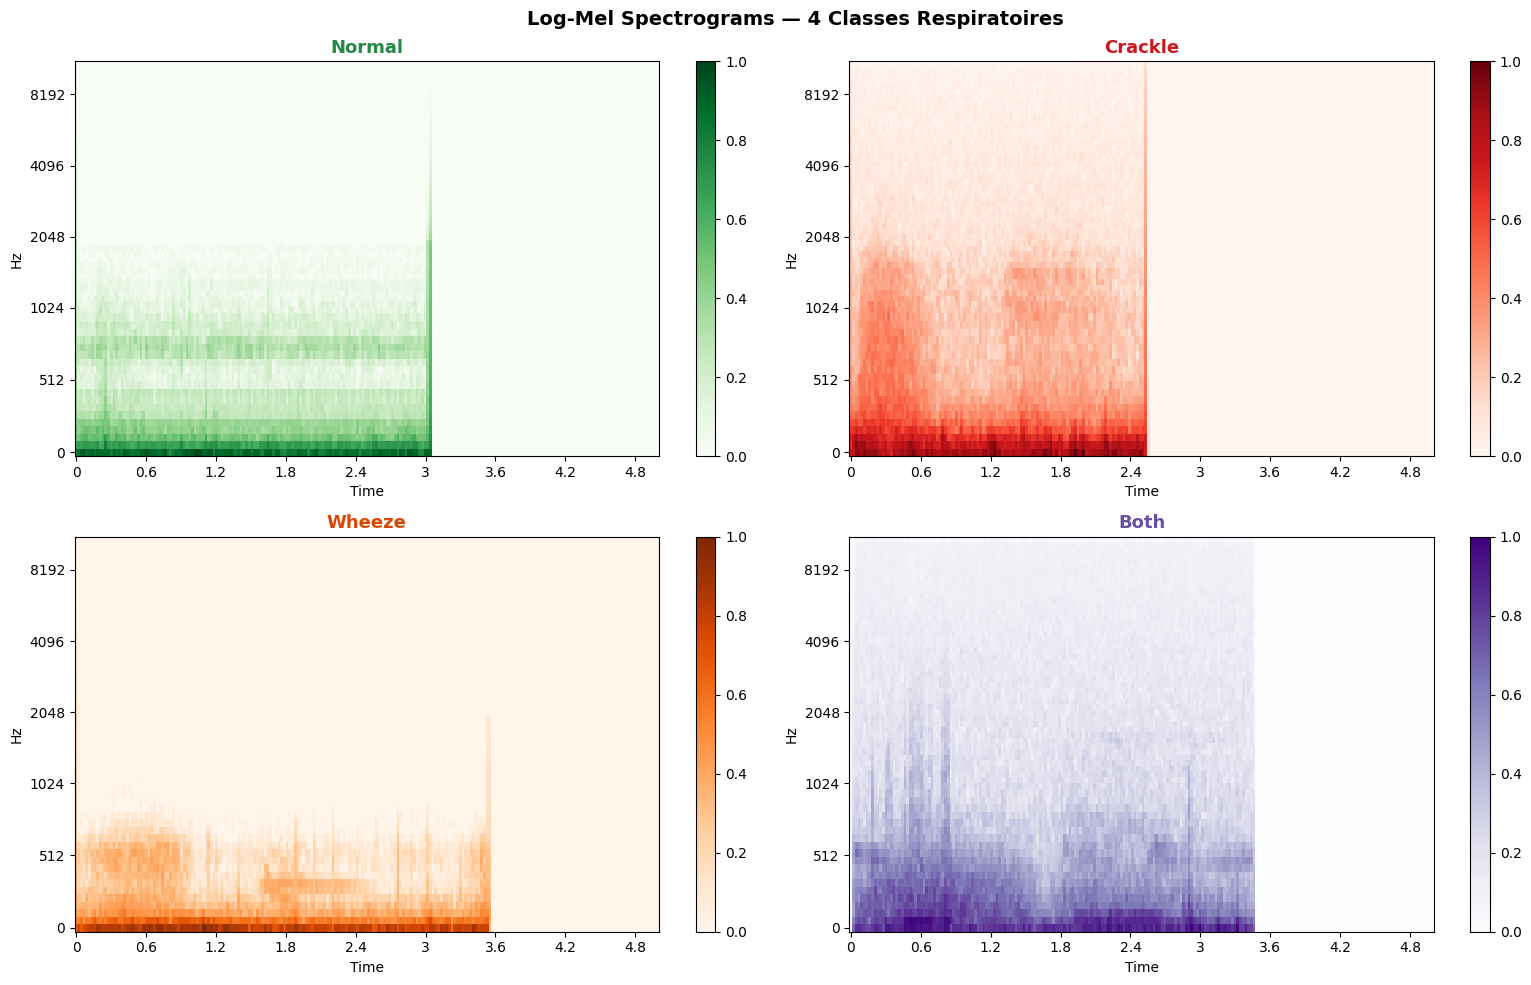


 Observations :
  Normal  → énergie homogène, pas de structure particulière
  Crackle → pics d'énergie discontinus, hautes fréquences
  Wheeze  → bandes horizontales continues, basses fréquences
  Both    → combinaison des deux patterns


In [37]:
# ── Visualisation des 4 classes ──────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Log-Mel Spectrograms — 4 Classes Respiratoires",
             fontsize=14, fontweight='bold')

cmaps = {'Normal':'Greens','Crackle':'Reds','Wheeze':'Oranges','Both':'Purples'}
for ax, (label, cmap) in zip(axes.flat, cmaps.items()):
    sample = df_audio[df_audio['label'] == label].sample(1, random_state=SEED).iloc[0]
    spec   = extract_log_mel(sample['audio_path'], sample['t_start'], sample['t_end'])
    if spec is not None:
        img = librosa.display.specshow(
            spec, sr=SR, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', ax=ax, cmap=cmap
        )
        plt.colorbar(img, ax=ax)
        ax.set_title(f'{label}', fontsize=13, fontweight='bold',
                     color=plt.get_cmap(cmap)(0.75))

plt.tight_layout()
plt.savefig('spectrograms_4classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Observations :")
print("  Normal  → énergie homogène, pas de structure particulière")
print("  Crackle → pics d'énergie discontinus, hautes fréquences")
print("  Wheeze  → bandes horizontales continues, basses fréquences")
print("  Both    → combinaison des deux patterns")

In [38]:
# ── Extraction de tous les spectrograms ─────────────────────────────
print(" Extraction en cours (10-15 min selon Colab)...")

le_audio  = LabelEncoder()
df_audio['label_id'] = le_audio.fit_transform(df_audio['label'])

X_audio, y_audio = [], []
for _, row in tqdm(df_audio.iterrows(), total=len(df_audio)):
    spec = extract_log_mel(row['audio_path'], row['t_start'], row['t_end'])
    if spec is not None:
        X_audio.append(spec)
        y_audio.append(row['label_id'])

# Ajouter la dimension canal → (N, mels, time, 1) attendu par Conv2D
X_audio = np.array(X_audio)[..., np.newaxis]
y_audio = np.array(y_audio)
NUM_CLASSES_AUDIO = len(le_audio.classes_)

print(f"\n Extraction terminée")
print(f"   X_audio shape : {X_audio.shape}")
print(f"   Classes       : {dict(enumerate(le_audio.classes_))}")

 Extraction en cours (10-15 min selon Colab)...


100%|██████████| 6898/6898 [02:08<00:00, 53.69it/s]



 Extraction terminée
   X_audio shape : (6898, 64, 216, 1)
   Classes       : {0: 'Both', 1: 'Crackle', 2: 'Normal', 3: 'Wheeze'}


In [39]:
# ── Split ────────────────────────────────────────────────────────────
X_tr_a, X_tmp_a, y_tr_a, y_tmp_a = train_test_split(
    X_audio, y_audio, test_size=0.30, random_state=SEED, stratify=y_audio)
X_val_a, X_test_a, y_val_a, y_test_a = train_test_split(
    X_tmp_a, y_tmp_a, test_size=0.50, random_state=SEED, stratify=y_tmp_a)

print(f"Train : {len(X_tr_a)} | Val : {len(X_val_a)} | Test : {len(X_test_a)}")
print(f"Shape d'un spectrogram : {X_audio.shape[1:]}  (mels × time × 1)")

Train : 4828 | Val : 1035 | Test : 1035
Shape d'un spectrogram : (64, 216, 1)  (mels × time × 1)


## 2.3 Modèle Custom — CNN 2D sur Log-Mel Spectrograms

### Pourquoi un CNN 2D ?

En transformant les sons en images spectrales, on peut exploiter les **réseaux
convolutifs** (CNN), qui sont l'architecture de référence pour la vision.

In [40]:
# ── Architecture CNN 2D ──────────────────────────────────────────────
def build_cnn_audio(input_shape, num_classes):
    inp = Input(shape=input_shape, name='spectrogram_input')

    # Bloc 1 — features bas niveau (textures spectrales)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 2 — features niveau intermédiaire (formes spectrales)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloc 3 — features haut niveau (patterns discriminants)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Classificateur
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN2D_Respiratory')

model_cnn = build_cnn_audio(X_audio.shape[1:], NUM_CLASSES_AUDIO)
model_cnn.summary()

Model: "CNN2D_Respiratory"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrogram_input (InputLayer)  │ (None, 64, 216, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 216, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 216, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 216, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 216, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 108, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 54, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,276 (1.23 MB)

 Trainable params: 321,380 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [41]:
# ── Compilation + class_weight ──────────────────────────────────────
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cw_audio = compute_class_weight('balanced', classes=np.unique(y_tr_a), y=y_tr_a)
cw_audio_dict = dict(enumerate(cw_audio))
print("Poids de classes audio :")
for k,v in cw_audio_dict.items():
    print(f"  {le_audio.classes_[k]:<10} → {v:.3f}")

Poids de classes audio :
  Both       → 3.410
  Crackle    → 0.925
  Normal     → 0.474
  Wheeze     → 1.947


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 652s 17s/step - accuracy: 0.3020 - loss: 1.3553 - val_accuracy: 0.2696 - val_loss: 1.4069 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 639s 17s/step - accuracy: 0.3399 - loss: 1.3215 - val_accuracy: 0.2696 - val_loss: 1.3572 - learning_rate: 0.0010
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 671s 16s/step - accuracy: 0.3492 - loss: 1.3036 - val_accuracy: 0.2696 - val_loss: 1.5662 - learning_rate: 0.0010
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 675s 16s/step - accuracy: 0.3757 - loss: 1.2716 - val_accuracy: 0.2696 - val_loss: 1.3251 - learning_rate: 0.0010
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 622s 16s/step - accuracy: 0.3830 - loss: 1.2638 - val_accuracy: 0.2696 - val_loss: 1.6384 - learning_rate: 0.0010
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 614s 16s/step - accuracy: 0.4093 - loss: 1.2263 - val_accuracy: 0.2696 - val_loss: 1.8692 - learning_rate: 0.0010
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4127 - loss: 1.2318 
Epo

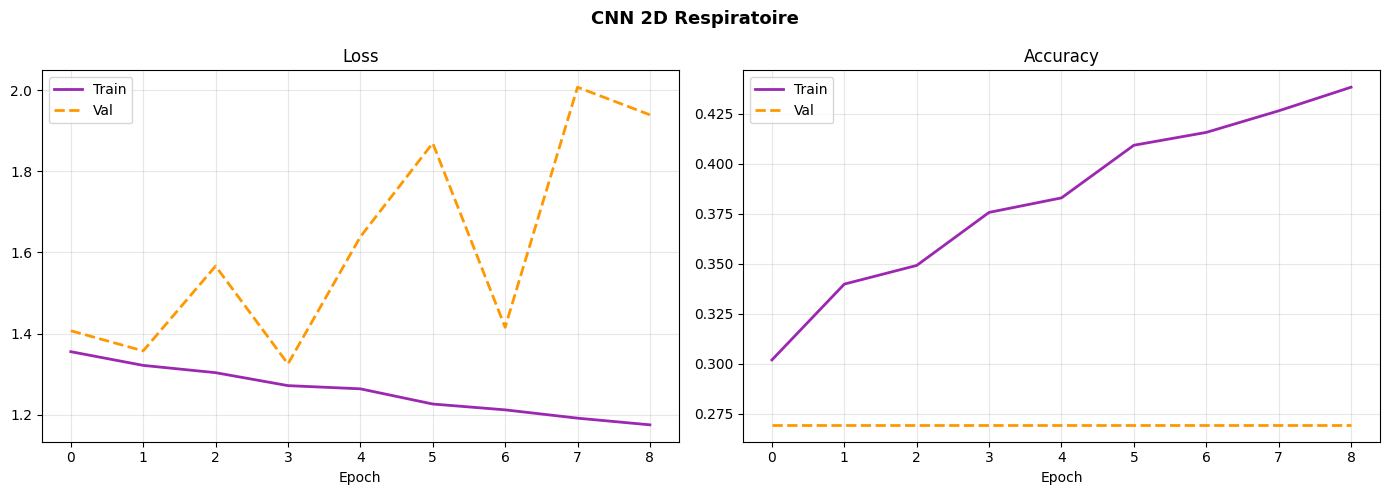

In [44]:
# ════════════════════════════════════════════════════════
#  CNN Audio — Augmentation + Entraînement RAPIDE
# ════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Data Augmentation ────────────────────────────────────
def augment_spectrogram(spec, label):
    noise = tf.random.normal(tf.shape(spec), stddev=0.015)
    return tf.clip_by_value(spec + noise, 0.0, 1.0), label

BATCH_CNN = 128                # ← 32→128
train_ds_a = (tf.data.Dataset.from_tensor_slices((X_tr_a, y_tr_a))
              .shuffle(500, seed=42)
              .map(augment_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_CNN).prefetch(tf.data.AUTOTUNE))

val_ds_a = (tf.data.Dataset.from_tensor_slices((X_val_a, y_val_a))
            .batch(BATCH_CNN).prefetch(tf.data.AUTOTUNE))

# ── Callbacks ────────────────────────────────────────────
cb_cnn = [
    EarlyStopping(monitor='val_loss', patience=5,   # ← 8→5
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_audio.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

# ── Entraînement ─────────────────────────────────────────
history_cnn = model_cnn.fit(
    train_ds_a,
    validation_data=val_ds_a,
    epochs=20,
    class_weight=cw_audio_dict,
    callbacks=cb_cnn,
    verbose=1
)

plot_history(history_cnn, "CNN 2D Respiratoire",
             color_train='#9C27B0', color_val='#FF9800')


════════════════════════════════════════════════════
  RÉSULTATS — CNN 2D Custom (Audio)
════════════════════════════════════════════════════
  Accuracy  : 0.2705
  F1 Macro  : 0.1065
════════════════════════════════════════════════════

              precision    recall  f1-score   support

        Both       0.00      0.00      0.00        76
     Crackle       0.27      1.00      0.43       280
      Normal       0.00      0.00      0.00       546
      Wheeze       0.00      0.00      0.00       133

    accuracy                           0.27      1035
   macro avg       0.07      0.25      0.11      1035
weighted avg       0.07      0.27      0.12      1035



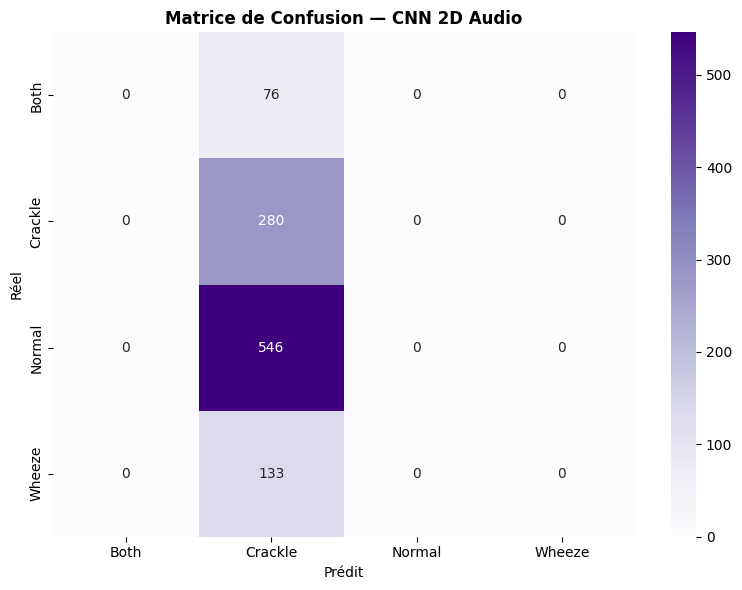

In [45]:
# ── Évaluation CNN Audio ─────────────────────────────────────────────
y_pred_cnn = np.argmax(model_cnn.predict(X_test_a, verbose=0), axis=1)
acc_cnn = accuracy_score(y_test_a, y_pred_cnn)
f1_cnn  = f1_score(y_test_a, y_pred_cnn, average='macro')

print(f"\n{'═'*52}")
print(f"  RÉSULTATS — CNN 2D Custom (Audio)")
print(f"{'═'*52}")
print(f"  Accuracy  : {acc_cnn:.4f}")
print(f"  F1 Macro  : {f1_cnn:.4f}")
print(f"{'═'*52}")
print()
print(classification_report(y_test_a, y_pred_cnn, target_names=le_audio.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a, y_pred_cnn), annot=True, fmt='d',
            cmap='Purples', xticklabels=le_audio.classes_, yticklabels=le_audio.classes_)
plt.title('Matrice de Confusion — CNN 2D Audio', fontweight='bold')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.savefig('confusion_cnn_audio.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Modèle Pré-entraîné — YAMNet (Transfer Learning)


In [46]:
# ── Chargement de YAMNet depuis TF Hub ──────────────────────────────
# TF Hub : dépôt officiel Google de modèles TensorFlow pré-entraînés.
# Avantage : téléchargement + chargement en une ligne, pas de gestion
# manuelle des poids.

print(" Chargement YAMNet depuis TF Hub ...")
yamnet = hub.load('https://tfhub.dev/google/yamnet/1')
print(" YAMNet chargé")
print("   Input attendu : signal float32, 16 kHz, normalisé [-1, 1]")
print("   Output        : (scores_521_classes, embeddings_1024, spectrogram)")

 Chargement YAMNet depuis TF Hub ...
 YAMNet chargé
   Input attendu : signal float32, 16 kHz, normalisé [-1, 1]
   Output        : (scores_521_classes, embeddings_1024, spectrogram)


In [47]:
# ── Extraction des embeddings YAMNet ─────────────────────────────────

YAMNET_SR = 16000   # fréquence native de YAMNet
N_YAM     = YAMNET_SR * DURATION

def extract_yamnet_embedding(audio_path, t_start, t_end):
    try:
        y, _ = librosa.load(audio_path, sr=YAMNET_SR,
                            offset=t_start, duration=(t_end - t_start))
        if len(y) < N_YAM:
            y = np.pad(y, (0, N_YAM - len(y)))
        else:
            y = y[:N_YAM]

        # Normalisation [-1, 1] obligatoire pour YAMNet
        y = y.astype(np.float32)
        y /= (np.max(np.abs(y)) + 1e-8)

        _, embeddings, _ = yamnet(y)       # embeddings : (n_frames, 1024)
        return tf.reduce_mean(embeddings, axis=0).numpy()  # mean pooling → (1024,)
    except Exception:
        return None

print("⏳ Extraction des embeddings YAMNet ...")
X_emb, y_emb = [], []
for _, row in tqdm(df_audio.iterrows(), total=len(df_audio)):
    emb = extract_yamnet_embedding(row['audio_path'], row['t_start'], row['t_end'])
    if emb is not None:
        X_emb.append(emb)
        y_emb.append(row['label_id'])

X_emb = np.array(X_emb, dtype=np.float32)
y_emb = np.array(y_emb)
print(f"\n Embeddings extraits : {X_emb.shape}  → (cycles, 1024)")

⏳ Extraction des embeddings YAMNet ...


100%|██████████| 6898/6898 [07:12<00:00, 15.94it/s]



 Embeddings extraits : (6898, 1024)  → (cycles, 1024)


In [48]:
# ── Split pour le classificateur YAMNet ─────────────────────────────
X_tr_e, X_tmp_e, y_tr_e, y_tmp_e = train_test_split(
    X_emb, y_emb, test_size=0.30, random_state=SEED, stratify=y_emb)
X_val_e, X_test_e, y_val_e, y_test_e = train_test_split(
    X_tmp_e, y_tmp_e, test_size=0.50, random_state=SEED, stratify=y_tmp_e)

In [49]:
# ── Classificateur MLP sur les embeddings ────────────────────────────

def build_yamnet_clf(num_classes):
    inp = Input(shape=(1024,), name='yamnet_embedding')
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name='YAMNet_MLP_Classifier')

model_yamnet = build_yamnet_clf(NUM_CLASSES_AUDIO)
model_yamnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cw_emb = dict(enumerate(
    compute_class_weight('balanced', classes=np.unique(y_tr_e), y=y_tr_e)
))

cb_yamnet = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]
model_yamnet.summary()

Model: "YAMNet_MLP_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ yamnet_embedding (InputLayer)   │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,836 (1.13 MB)

 Trainable params: 296,324 (1.13 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2802 - loss: 1.6204 - val_accuracy: 0.5092 - val_loss: 1.2491 - learning_rate: 0.0010
Epoch 2/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3051 - loss: 1.4858 - val_accuracy: 0.4812 - val_loss: 1.2354 - learning_rate: 0.0010
Epoch 3/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3239 - loss: 1.4030 - val_accuracy: 0.3874 - val_loss: 1.2803 - learning_rate: 0.0010
Epoch 4/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3262 - loss: 1.3910 - val_accuracy: 0.5198 - val_loss: 1.2097 - learning_rate: 0.0010
Epoch 5/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3449 - loss: 1.3317 - val_accuracy: 0.4696 - val_loss: 1.2499 - learning_rate: 0.0010
Epoch 6/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3420 - loss: 1.3307 - val_accuracy: 0.2251 - val_loss: 1.4585 - learning_rate: 0.0010
Epoch 7/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3370 - loss: 1.3157 - val_acc

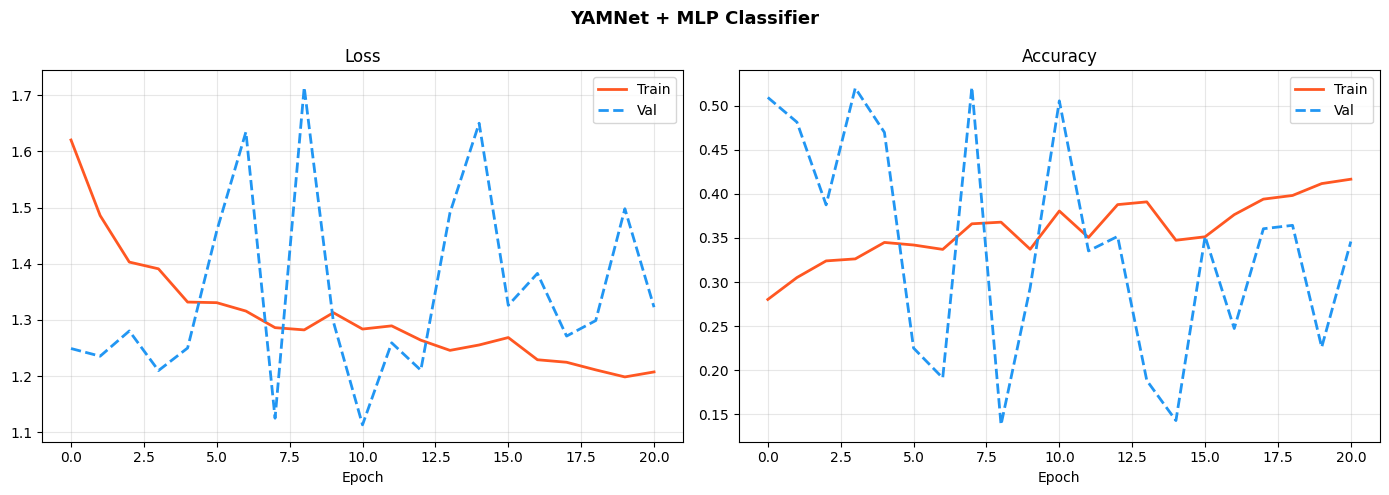

In [50]:
# ── Entraînement ─────────────────────────────────────────────────────
# batch_size=64 : les embeddings sont légers (1024 float32 par sample)
# On peut se permettre un batch plus grand → convergence plus rapide.
history_yamnet = model_yamnet.fit(
    X_tr_e, y_tr_e,
    validation_data=(X_val_e, y_val_e),
    epochs=60,
    batch_size=64,
    class_weight=cw_emb,
    callbacks=cb_yamnet,
    verbose=1
)
plot_history(history_yamnet, "YAMNet + MLP Classifier",
             color_train='#FF5722', color_val='#2196F3')


════════════════════════════════════════════════════
  RÉSULTATS — YAMNet + MLP (Transfer Learning)
════════════════════════════════════════════════════
  Accuracy  : 0.5179
  F1 Macro  : 0.2953
════════════════════════════════════════════════════

              precision    recall  f1-score   support

        Both       0.14      0.07      0.09        76
     Crackle       0.43      0.31      0.36       280
      Normal       0.56      0.80      0.66       546
      Wheeze       0.36      0.04      0.07       133

    accuracy                           0.52      1035
   macro avg       0.37      0.30      0.30      1035
weighted avg       0.47      0.52      0.46      1035



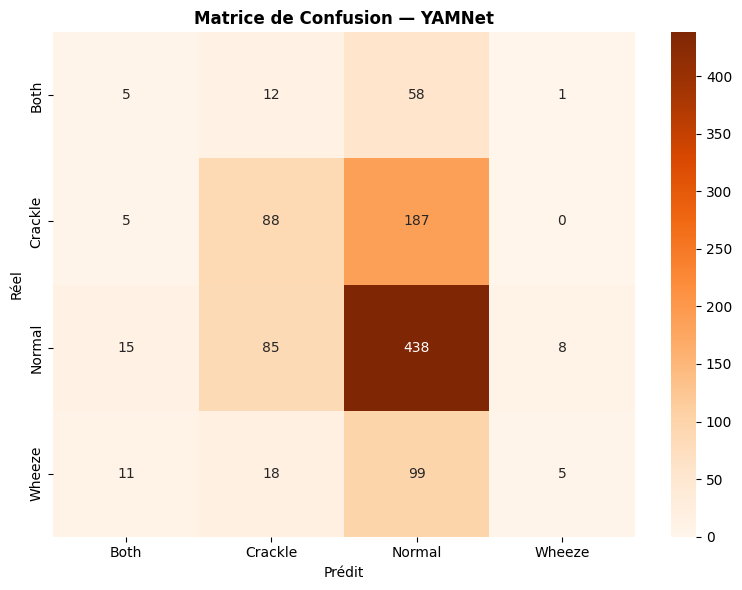

In [51]:
# ── Évaluation YAMNet ────────────────────────────────────────────────
y_pred_yamnet = np.argmax(model_yamnet.predict(X_test_e, verbose=0), axis=1)
acc_yamnet = accuracy_score(y_test_e, y_pred_yamnet)
f1_yamnet  = f1_score(y_test_e, y_pred_yamnet, average='macro')

print(f"\n{'═'*52}")
print(f"  RÉSULTATS — YAMNet + MLP (Transfer Learning)")
print(f"{'═'*52}")
print(f"  Accuracy  : {acc_yamnet:.4f}")
print(f"  F1 Macro  : {f1_yamnet:.4f}")
print(f"{'═'*52}")
print()
print(classification_report(y_test_e, y_pred_yamnet, target_names=le_audio.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_e, y_pred_yamnet), annot=True, fmt='d',
            cmap='Oranges', xticklabels=le_audio.classes_, yticklabels=le_audio.classes_)
plt.title('Matrice de Confusion — YAMNet', fontweight='bold')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.savefig('confusion_yamnet.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ── Export JSON des résultats ────────────────────────────────────────
# Ce fichier est partagé avec le membre de l'équipe chargé
# de l'étude comparative globale du projet.

results = {
    "texte": {
        "dataset": "MTSamples Medical Transcriptions (Kaggle · tboyle10)",
        "nb_classes": NUM_CLASSES,
        "classes": list(le.classes_),
        "nb_docs_test": int(len(y_test)),
        "BiLSTM_Attention": {
            "type": "custom",
            "accuracy": float(acc_bilstm),
            "f1_macro": float(f1_bilstm),
            "params_approx": "~2.5M"
        },
        "ClinicalBERT": {
            "type": "pretrained",
            "base_model": "emilyalsentzer/Bio_ClinicalBERT",
            "accuracy": float(acc_bert),
            "f1_macro": float(f1_bert),
            "params_approx": "~110M"
        }
    },
    "audio": {
        "dataset": "ICBHI 2017 Respiratory Sound Database (Kaggle)",
        "nb_classes": NUM_CLASSES_AUDIO,
        "classes": list(le_audio.classes_),
        "nb_cycles_test": int(len(y_test_a)),
        "CNN2D": {
            "type": "custom",
            "features": "Log-Mel Spectrogram (64 mels)",
            "accuracy": float(acc_cnn),
            "f1_macro": float(f1_cnn),
            "params_approx": "~1.2M"
        },
        "YAMNet_MLP": {
            "type": "transfer_learning",
            "base_model": "google/yamnet (TF Hub)",
            "accuracy": float(acc_yamnet),
            "f1_macro": float(f1_yamnet),
            "params_approx": "~3.7M (gelé) + 0.4M (MLP)"
        }
    }
}

with open('results_texte_audio.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(" results_texte_audio.json exporté")
print()
# Récapitulatif lisible
print(f"{'═'*60}")
print(f"  RÉCAPITULATIF COMPLET")
print(f"{'═'*60}")
print(f"  {'Modalité':<10} {'Modèle':<30} {'Acc':>7} {'F1':>7}")
print(f"  {'─'*56}")
print(f"  {'Texte':<10} {'BiLSTM + Attention (custom)':<30} {acc_bilstm:>7.4f} {f1_bilstm:>7.4f}")
print(f"  {'Texte':<10} {'ClinicalBERT (pré-entraîné)':<30} {acc_bert:>7.4f} {f1_bert:>7.4f}")
print(f"  {'Audio':<10} {'CNN 2D (custom)':<30} {acc_cnn:>7.4f} {f1_cnn:>7.4f}")
print(f"  {'Audio':<10} {'YAMNet + MLP (transfer)':<30} {acc_yamnet:>7.4f} {f1_yamnet:>7.4f}")
print(f"{'═'*60}")
print()
print(" Fichiers générés :")
files_gen = [
    "text_eda.png               — EDA MTSamples",
    "audio_eda.png              — EDA ICBHI 2017",
    "spectrograms_4classes.png  — Visualisation spectrograms par classe",
    "BiLSTM_+_Attention.png     — Courbes entraînement BiLSTM",
    "ClinicalBERT_Fine-tuning.png — Courbes entraînement BERT",
    "CNN_2D_Respiratoire.png    — Courbes entraînement CNN audio",
    "YAMNet_+_MLP_Classifier.png — Courbes entraînement YAMNet",
    "confusion_bilstm.png       — Matrice confusion BiLSTM",
    "confusion_bert.png         — Matrice confusion ClinicalBERT",
    "confusion_cnn_audio.png    — Matrice confusion CNN audio",
    "confusion_yamnet.png       — Matrice confusion YAMNet",
    "best_bilstm.keras          — Meilleurs poids BiLSTM",
    "best_cnn_audio.keras       — Meilleurs poids CNN audio",
    "results_texte_audio.json   — Résultats numériques (pour comparaison équipe)",
]
for f in files_gen:
    print(f"   • {f}")

 results_texte_audio.json exporté

════════════════════════════════════════════════════════════
  RÉCAPITULATIF COMPLET
════════════════════════════════════════════════════════════
  Modalité   Modèle                             Acc      F1
  ────────────────────────────────────────────────────────
  Texte      BiLSTM + Attention (custom)     0.4041  0.2976
  Texte      ClinicalBERT (pré-entraîné)     0.1043  0.0343
  Audio      CNN 2D (custom)                 0.2705  0.1065
  Audio      YAMNet + MLP (transfer)         0.5179  0.2953
════════════════════════════════════════════════════════════

 Fichiers générés :
   • text_eda.png               — EDA MTSamples
   • audio_eda.png              — EDA ICBHI 2017
   • spectrograms_4classes.png  — Visualisation spectrograms par classe
   • BiLSTM_+_Attention.png     — Courbes entraînement BiLSTM
   • ClinicalBERT_Fine-tuning.png — Courbes entraînement BERT
   • CNN_2D_Respiratoire.png    — Courbes entraînement CNN audio
   • YAMNet_+_MLP_Cl